In [1]:
import numpy as np
import psfsim
import matplotlib.pyplot as plt
import matplotlib as mpl

from psfsim.psfobject import PSFObject

In [2]:
def line_coords( angle, bound, center=np.array( ( 0, 0 ) ) ):
    # since (0, 0) in data coords is top left instead of bottom left we must use clockwise rotations to get
    # a visually ccl rotation. However we will take a transpose later anyways so the rotation matrix def is ccl, as expected. How quaint
    angle = np.deg2rad( angle )
    # print( angle )
    line = np.zeros( ( 2, bound ) )
    line[0] = np.arange( bound )

    rotation = np.array( (
        ( np.cos( angle ), -np.sin( angle ) ),
        ( np.sin( angle ), np.cos( angle ) ),
    ) )

    if len( rotation.shape ) > 2:
        line = line.reshape( ( 1, 2, bound ) )

    # print( line.shape )
    # print( rotation.T.shape )
    
    return np.int32( rotation.T @ line ) + np.int32( np.reshape( center, ( 2, 1 ) ) )

angle = 112 # degrees
bound = 2048 // 2

def find_spikes( image, step, bound=1024, center=np.array( ( 0, 0 ) ), exclude_center=False, verbose=False ):

    # TODO: Prominence and Spike width
    # prominence filtering is the next step up in analyzing the sums plot to find spikes. While it is true that small aberrations
    # are easy to analyze, spike width and prominence (brightness vs background) may prove to be valuable pieces of information
    # later on. Also I would like to figure out how to find the spikes in difficult situations.
    #
    #
    #

    
    angles = np.linspace( 0, 360, num=np.int32( 360. / step ), endpoint=False )

    lines = line_coords( angles, bound, center )
    image_analyze = image.T # imshow will display the image as row,col with 0,0 in top left. For our analysis we want (col,row).
    
    line_vals = image_analyze[ lines[:,0], lines[:,1] ]
    print( line_vals.shape )
    if exclude_center:
        sums = np.sum( line_vals[:, (bound // 2): ], axis=-1 )
    else:
        sums = np.sum( line_vals, axis=-1 )
    '''
    This simple midpoint formula is the first attempt at discriminating maxima from each other. If we want to find less well-defined spikes
    this could become more challenging.
    '''
    cutoff = ( np.min( sums ) + np.max( sums ) ) / 2
    spike_indices = np.where( sums > cutoff )[0]
    spike_angles = angles[ spike_indices ]
    # print( np.diff( spike_angles ) )

    # try 3 degrees to tell differing spikes apart for now
    spike_angle_discriminator = 3.
    borders = np.where( np.diff( spike_angles ) > spike_angle_discriminator )[0]
    spike_groups = np.split( spike_angles, borders + 1 )
    # print( spike_groups )

    # unfortunately this for loop is necessary unless theres a convenient package for jagged arrays
    spike_list = np.zeros( len( spike_groups ) )
    for i in np.arange( len( spike_groups ) ):
        spike_list[i] = np.median( spike_groups[i] )

    # print( spike_list )
    if verbose:
        return sums, spike_angles, cutoff, spike_list
    else:
        return spike_list

def draw_ray( ax, angle, bound, center=np.array( ( 0, 0 ) ), borders=( 0., 1. ), **kwargs ):
    line = line_coords( angle, bound, center )
    range_low = np.int_( borders[0] * bound )
    range_high = np.int_( borders[1] * bound )
    ax.plot( line[ 0, range_low:range_high ], line[ 1, range_low:range_high ], **kwargs )
    return

def downsample_2d_image( image, pixel_size=8 ): # ONLY WORKS ON 2D IMAGES
    subpixel_side = np.arange( pixel_size )
    subpixel_cols, subpixel_rows = np.meshgrid( subpixel_side, subpixel_side )

    dsamp_size = image.shape[0] // pixel_size
    pixels_side = np.arange( dsamp_size ) * pixel_size
    pixels_cols, pixels_rows = np.meshgrid( pixels_side, pixels_side )
    
    pixels_rows = pixels_rows[ :, :, np.newaxis ] # promote to 3D
    pixels_cols = pixels_cols[ :, :, np.newaxis ]
    
    idx_arr_subpixel_rows = np.full( ( dsamp_size, dsamp_size, pixel_size**2 ), subpixel_rows.flatten( ) )
    idx_arr_subpixel_cols = np.full( ( dsamp_size, dsamp_size, pixel_size**2 ), subpixel_cols.flatten( ) )
    
    idx_arr_rows = idx_arr_subpixel_rows + pixels_rows
    idx_arr_cols = idx_arr_subpixel_cols + pixels_cols
    
    pixelated_image = image[ idx_arr_rows, idx_arr_cols ]
    downsampled_image = np.mean( pixelated_image, axis=-1 )
    return downsampled_image

In [3]:
# want an ideal and a display for each aberration

obj = PSFObject(
    9,0,0, wavelength=1.25, postage_stamp_size=32, use_postage_stamp_size=None,
)
obj.get_optical_psf( )
psf_ideal = np.log10( np.abs( obj.Optical_PSF ) )

/apps/python/3.12/lib/python3.12/site-packages/numpy/core/fromnumeric.py:3504: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/apps/python/3.12/lib/python3.12/site-packages/numpy/core/_methods.py:121: RuntimeWarning: invalid value encountered in divide
  ret = um.true_divide(


Bounding pupil width determined from initial ray trace: 2859.38 mm


In [4]:
obj = PSFObject(
    9,0,0, wavelength=1.25, postage_stamp_size=32, use_postage_stamp_size=None,
    extra_aberrations=( 5., )
)
obj.get_optical_psf( )
psf_hcenter = np.log10( np.abs( obj.Optical_PSF ) )

/apps/python/3.12/lib/python3.12/site-packages/numpy/core/fromnumeric.py:3504: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/apps/python/3.12/lib/python3.12/site-packages/numpy/core/_methods.py:121: RuntimeWarning: invalid value encountered in divide
  ret = um.true_divide(


Bounding pupil width determined from initial ray trace: 2859.38 mm


In [5]:
obj = PSFObject(
    9,0,0, wavelength=1.25, postage_stamp_size=32, use_postage_stamp_size=None,
    extra_aberrations=( None, 5., )
)
obj.get_optical_psf( )
psf_vcenter = np.log10( np.abs( obj.Optical_PSF ) )

/apps/python/3.12/lib/python3.12/site-packages/numpy/core/fromnumeric.py:3504: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/apps/python/3.12/lib/python3.12/site-packages/numpy/core/_methods.py:121: RuntimeWarning: invalid value encountered in divide
  ret = um.true_divide(


Bounding pupil width determined from initial ray trace: 2859.38 mm


In [6]:
obj = PSFObject(
    9,0,0, wavelength=1.25, postage_stamp_size=32, use_postage_stamp_size=None,
    extra_aberrations=( None, None, 1. )
)
obj.get_optical_psf( )
psf_focus = np.log10( np.abs( obj.Optical_PSF ) )

/apps/python/3.12/lib/python3.12/site-packages/numpy/core/fromnumeric.py:3504: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/apps/python/3.12/lib/python3.12/site-packages/numpy/core/_methods.py:121: RuntimeWarning: invalid value encountered in divide
  ret = um.true_divide(


Bounding pupil width determined from initial ray trace: 2859.38 mm


In [7]:
obj = PSFObject(
    9,0,0, wavelength=1.25, postage_stamp_size=32, use_postage_stamp_size=None,
    extra_aberrations=( None, None, None, 1. )
)
obj.get_optical_psf( )
psf_xastigmatism = np.log10( np.abs( obj.Optical_PSF ) )

/apps/python/3.12/lib/python3.12/site-packages/numpy/core/fromnumeric.py:3504: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/apps/python/3.12/lib/python3.12/site-packages/numpy/core/_methods.py:121: RuntimeWarning: invalid value encountered in divide
  ret = um.true_divide(


Bounding pupil width determined from initial ray trace: 2859.38 mm


In [8]:
obj = PSFObject(
    9,0,0, wavelength=1.25, postage_stamp_size=32, use_postage_stamp_size=None,
    extra_aberrations=( None, None, None, None, 1. )
)
obj.get_optical_psf( )
psf_pastigmatism = np.log10( np.abs( obj.Optical_PSF ) )

/apps/python/3.12/lib/python3.12/site-packages/numpy/core/fromnumeric.py:3504: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/apps/python/3.12/lib/python3.12/site-packages/numpy/core/_methods.py:121: RuntimeWarning: invalid value encountered in divide
  ret = um.true_divide(


Bounding pupil width determined from initial ray trace: 2859.38 mm


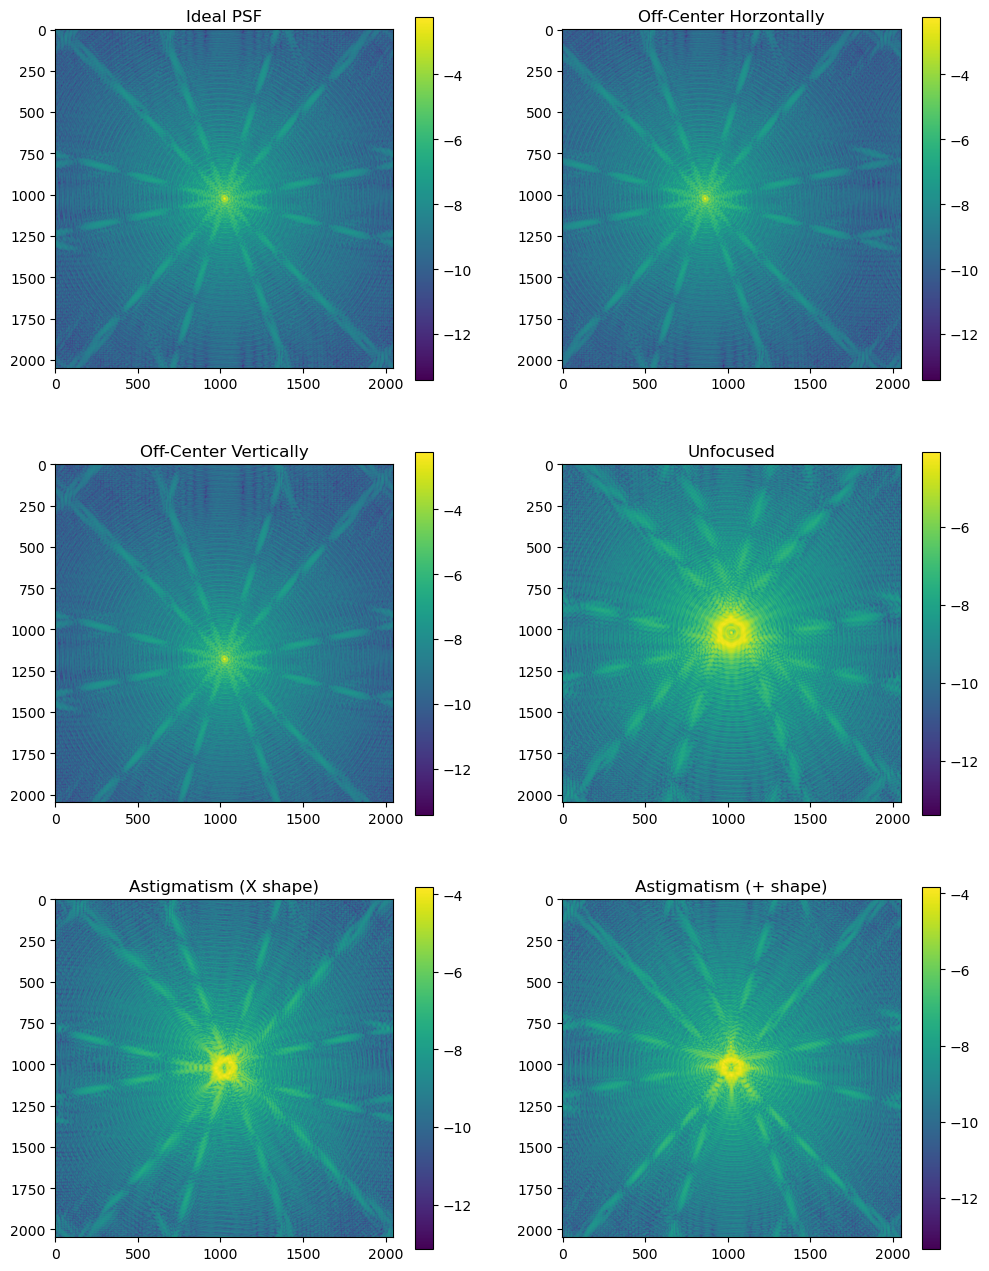

In [9]:
fig, ax = plt.subplots( figsize=( 12, 16 ), nrows=3, ncols=2 )

im = ax[0,0].imshow( psf_ideal )
fig.colorbar( im, ax=ax[0,0] )

im = ax[0,1].imshow( psf_hcenter )
fig.colorbar( im, ax=ax[0,1] )

im = ax[1,0].imshow( psf_vcenter )
fig.colorbar( im, ax=ax[1,0] )

im = ax[1,1].imshow( psf_focus )
fig.colorbar( im, ax=ax[1,1] )

im = ax[2,0].imshow( psf_xastigmatism )
fig.colorbar( im, ax=ax[2,0] )

im = ax[2,1].imshow( psf_pastigmatism )
fig.colorbar( im, ax=ax[2,1] );

ax[0,0].set_title( 'Ideal PSF' )
ax[0,1].set_title( 'Off-Center Horzontally' )
ax[1,0].set_title( 'Off-Center Vertically' )
ax[1,1].set_title( 'Unfocused' )
ax[2,0].set_title( 'Astigmatism (X shape)' )
ax[2,1].set_title( 'Astigmatism (+ shape)' );

In [10]:
obj = PSFObject(
    9,0,0, wavelength=1.25, postage_stamp_size=32, use_postage_stamp_size=None,
    extra_aberrations=( None, None, 0.1 )
)
obj.get_optical_psf( )
psf_focus_pos = np.log10( np.abs( obj.Optical_PSF ) )

/apps/python/3.12/lib/python3.12/site-packages/numpy/core/fromnumeric.py:3504: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/apps/python/3.12/lib/python3.12/site-packages/numpy/core/_methods.py:121: RuntimeWarning: invalid value encountered in divide
  ret = um.true_divide(


Bounding pupil width determined from initial ray trace: 2859.38 mm


In [11]:
obj = PSFObject(
    9,0,0, wavelength=1.25, postage_stamp_size=32, use_postage_stamp_size=None,
    extra_aberrations=( None, None, -0.1 )
)
obj.get_optical_psf( )
psf_focus_neg = np.log10( np.abs( obj.Optical_PSF ) )

/apps/python/3.12/lib/python3.12/site-packages/numpy/core/fromnumeric.py:3504: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/apps/python/3.12/lib/python3.12/site-packages/numpy/core/_methods.py:121: RuntimeWarning: invalid value encountered in divide
  ret = um.true_divide(


Bounding pupil width determined from initial ray trace: 2859.38 mm


In [12]:
obj = PSFObject(
    9,0,0, wavelength=1.25, postage_stamp_size=32, use_postage_stamp_size=None,
    extra_aberrations=( None, None, 0.03 )
)
obj.get_optical_psf( )
psf_focus_small = np.log10( np.abs( obj.Optical_PSF ) )

/apps/python/3.12/lib/python3.12/site-packages/numpy/core/fromnumeric.py:3504: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/apps/python/3.12/lib/python3.12/site-packages/numpy/core/_methods.py:121: RuntimeWarning: invalid value encountered in divide
  ret = um.true_divide(


Bounding pupil width determined from initial ray trace: 2859.38 mm


(3600, 1024)
(3600, 1024)
(3600, 1024)
(3600, 1024)


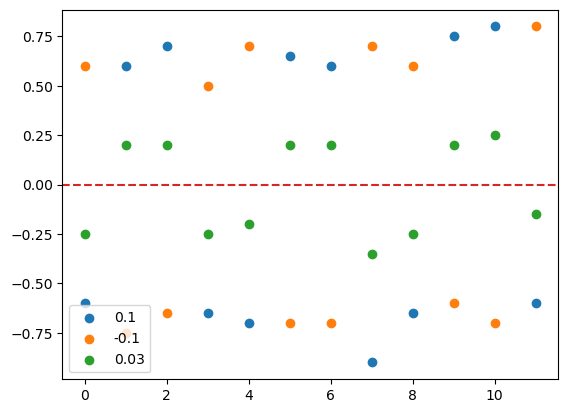

In [13]:
dim = psf_ideal.shape[0]
bound = dim // 2
center = ( dim // 2, dim // 2 )
step = 0.1

sums_ideal, _, cutoff_ideal, spike_list_ideal = find_spikes( psf_ideal, step, bound, center, verbose=True )
spike_list_focus_pos = find_spikes( psf_focus_pos, step, bound, center )
spike_list_focus_neg = find_spikes( psf_focus_neg, step, bound, center )
spike_list_focus_small = find_spikes( psf_focus_small, step, bound, center )
N = np.arange( spike_list_ideal.size )

fig2, ax2 = plt.subplots( )
ax2.scatter( N, spike_list_focus_pos - spike_list_ideal, label='0.1' )
ax2.scatter( N, spike_list_focus_neg - spike_list_ideal, label='-0.1' )
ax2.scatter( N, spike_list_focus_small - spike_list_ideal, label='0.03' )
ax2.axhline( 0, color='C3', ls='--' )
ax2.legend( );

In [14]:
obj = PSFObject(
    9,0,0, wavelength=1.25, postage_stamp_size=32, use_postage_stamp_size=None,
    extra_aberrations=( None, None, None, 0.1 )
)
obj.get_optical_psf( )
psf_xast_pos = np.log10( np.abs( obj.Optical_PSF ) )

/apps/python/3.12/lib/python3.12/site-packages/numpy/core/fromnumeric.py:3504: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/apps/python/3.12/lib/python3.12/site-packages/numpy/core/_methods.py:121: RuntimeWarning: invalid value encountered in divide
  ret = um.true_divide(


Bounding pupil width determined from initial ray trace: 2859.38 mm


In [15]:
obj = PSFObject(
    9,0,0, wavelength=1.25, postage_stamp_size=32, use_postage_stamp_size=None,
    extra_aberrations=( None, None, None, -0.1 )
)
obj.get_optical_psf( )
psf_xast_neg = np.log10( np.abs( obj.Optical_PSF ) )

/apps/python/3.12/lib/python3.12/site-packages/numpy/core/fromnumeric.py:3504: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/apps/python/3.12/lib/python3.12/site-packages/numpy/core/_methods.py:121: RuntimeWarning: invalid value encountered in divide
  ret = um.true_divide(


Bounding pupil width determined from initial ray trace: 2859.38 mm


In [16]:
obj = PSFObject(
    9,0,0, wavelength=1.25, postage_stamp_size=32, use_postage_stamp_size=None,
    extra_aberrations=( None, None, None, 0.03 )
)
obj.get_optical_psf( )
psf_xast_small = np.log10( np.abs( obj.Optical_PSF ) )

/apps/python/3.12/lib/python3.12/site-packages/numpy/core/fromnumeric.py:3504: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/apps/python/3.12/lib/python3.12/site-packages/numpy/core/_methods.py:121: RuntimeWarning: invalid value encountered in divide
  ret = um.true_divide(


Bounding pupil width determined from initial ray trace: 2859.38 mm


(3600, 1024)
(3600, 1024)
(3600, 1024)


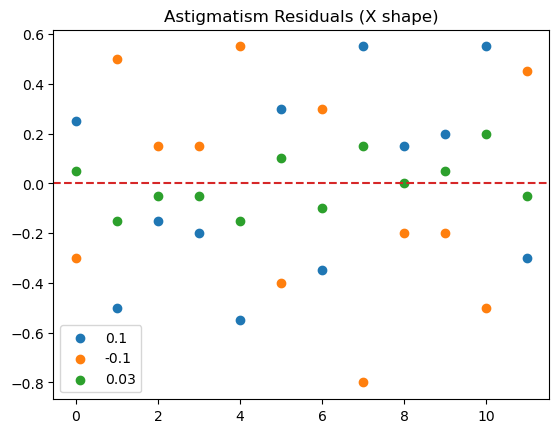

In [17]:
spike_list_xast_pos = find_spikes( psf_xast_pos, step, bound, center )
spike_list_xast_neg = find_spikes( psf_xast_neg, step, bound, center )
spike_list_xast_small = find_spikes( psf_xast_small, step, bound, center )
N = np.arange( spike_list_ideal.size )

fig3, ax3 = plt.subplots( )
ax3.scatter( N, spike_list_xast_pos - spike_list_ideal, label='0.1' )
ax3.scatter( N, spike_list_xast_neg - spike_list_ideal, label='-0.1' )
ax3.scatter( N, spike_list_xast_small - spike_list_ideal, label='0.03' )
ax3.axhline( 0, color='C3', ls='--' )
ax3.set_title( 'Astigmatism Residuals (X shape)' )
ax3.legend( );

In [18]:
obj = PSFObject(
    9,0,0, wavelength=1.25, postage_stamp_size=32, use_postage_stamp_size=None,
    extra_aberrations=( None, None, None, None, 0.1 )
)
obj.get_optical_psf( )
psf_past_pos = np.log10( np.abs( obj.Optical_PSF ) )

/apps/python/3.12/lib/python3.12/site-packages/numpy/core/fromnumeric.py:3504: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/apps/python/3.12/lib/python3.12/site-packages/numpy/core/_methods.py:121: RuntimeWarning: invalid value encountered in divide
  ret = um.true_divide(


Bounding pupil width determined from initial ray trace: 2859.38 mm


In [19]:
obj = PSFObject(
    9,0,0, wavelength=1.25, postage_stamp_size=32, use_postage_stamp_size=None,
    extra_aberrations=( None, None, None, None, -0.1 )
)
obj.get_optical_psf( )
psf_past_neg = np.log10( np.abs( obj.Optical_PSF ) )

/apps/python/3.12/lib/python3.12/site-packages/numpy/core/fromnumeric.py:3504: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/apps/python/3.12/lib/python3.12/site-packages/numpy/core/_methods.py:121: RuntimeWarning: invalid value encountered in divide
  ret = um.true_divide(


Bounding pupil width determined from initial ray trace: 2859.38 mm


In [20]:
obj = PSFObject(
    9,0,0, wavelength=1.25, postage_stamp_size=32, use_postage_stamp_size=None,
    extra_aberrations=( None, None, None, None, 0.03 )
)
obj.get_optical_psf( )
psf_past_small = np.log10( np.abs( obj.Optical_PSF ) )

/apps/python/3.12/lib/python3.12/site-packages/numpy/core/fromnumeric.py:3504: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/apps/python/3.12/lib/python3.12/site-packages/numpy/core/_methods.py:121: RuntimeWarning: invalid value encountered in divide
  ret = um.true_divide(


Bounding pupil width determined from initial ray trace: 2859.38 mm


(3600, 1024)
(3600, 1024)
(3600, 1024)
0.05000000000001137


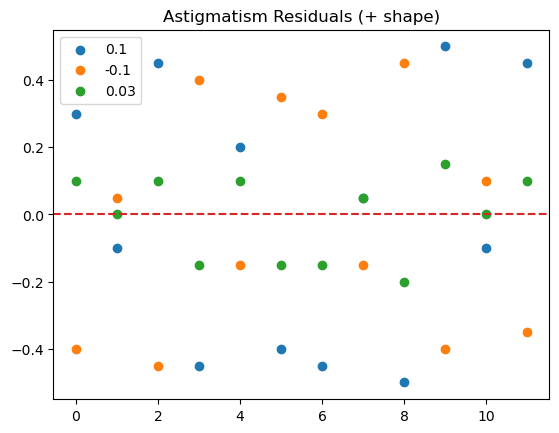

In [21]:
spike_list_past_pos = find_spikes( psf_past_pos, step, bound, center )
spike_list_past_neg = find_spikes( psf_past_neg, step, bound, center )
spike_list_past_small = find_spikes( psf_past_small, step, bound, center )
N = np.arange( spike_list_ideal.size )

fig3, ax3 = plt.subplots( )
ax3.scatter( N, spike_list_past_pos - spike_list_ideal, label='0.1' )
ax3.scatter( N, spike_list_past_neg - spike_list_ideal, label='-0.1' )
ax3.scatter( N, spike_list_past_small - spike_list_ideal, label='0.03' )
ax3.axhline( 0, color='C3', ls='--' )
ax3.set_title( 'Astigmatism Residuals (+ shape)' )
ax3.legend( );
print( ( spike_list_past_small - spike_list_ideal )[7] )

In [22]:
obj = PSFObject(
    9,0,0, wavelength=1.25, postage_stamp_size=32, use_postage_stamp_size=None,
    extra_aberrations=( 0.1, )
)
obj.get_optical_psf( )
psf_hcenter_pos = np.log10( np.abs( obj.Optical_PSF ) )

/apps/python/3.12/lib/python3.12/site-packages/numpy/core/fromnumeric.py:3504: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/apps/python/3.12/lib/python3.12/site-packages/numpy/core/_methods.py:121: RuntimeWarning: invalid value encountered in divide
  ret = um.true_divide(


Bounding pupil width determined from initial ray trace: 2859.38 mm


In [23]:
obj = PSFObject(
    9,0,0, wavelength=1.25, postage_stamp_size=32, use_postage_stamp_size=None,
    extra_aberrations=( -0.1, )
)
obj.get_optical_psf( )
psf_hcenter_neg = np.log10( np.abs( obj.Optical_PSF ) )

/apps/python/3.12/lib/python3.12/site-packages/numpy/core/fromnumeric.py:3504: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/apps/python/3.12/lib/python3.12/site-packages/numpy/core/_methods.py:121: RuntimeWarning: invalid value encountered in divide
  ret = um.true_divide(


Bounding pupil width determined from initial ray trace: 2859.38 mm


In [24]:
obj = PSFObject(
    9,0,0, wavelength=1.25, postage_stamp_size=32, use_postage_stamp_size=None,
    extra_aberrations=( 0.03, )
)
obj.get_optical_psf( )
psf_hcenter_small = np.log10( np.abs( obj.Optical_PSF ) )

/apps/python/3.12/lib/python3.12/site-packages/numpy/core/fromnumeric.py:3504: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/apps/python/3.12/lib/python3.12/site-packages/numpy/core/_methods.py:121: RuntimeWarning: invalid value encountered in divide
  ret = um.true_divide(


Bounding pupil width determined from initial ray trace: 2859.38 mm


(3600, 1024)
(3600, 1024)
(3600, 1024)
0.05000000000001137
344.90000000000003
344.95000000000005


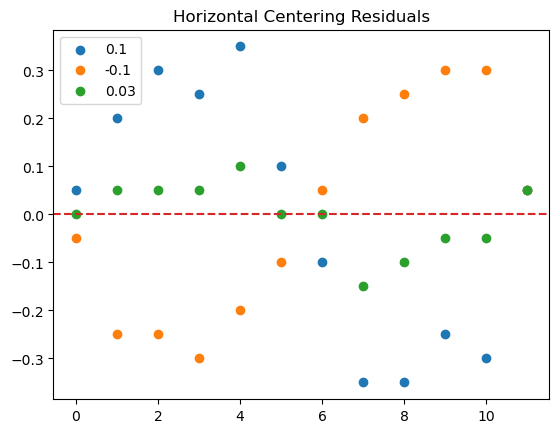

In [25]:
sums_hcenter_pos, _, cutoff_hcenter_pos, spike_list_hcenter_pos = find_spikes( psf_hcenter_pos, step, bound, center, verbose=True )
spike_list_hcenter_neg = find_spikes( psf_hcenter_neg, step, bound, center )
spike_list_hcenter_small = find_spikes( psf_hcenter_small, step, bound, center )
N = np.arange( spike_list_ideal.size )

fig4, ax4 = plt.subplots( )
ax4.scatter( N, spike_list_hcenter_pos - spike_list_ideal, label='0.1' )
ax4.scatter( N, spike_list_hcenter_neg - spike_list_ideal, label='-0.1' )
ax4.scatter( N, spike_list_hcenter_small - spike_list_ideal, label='0.03' )
ax4.axhline( 0, color='C3', ls='--' )
ax4.set_title( 'Horizontal Centering Residuals' )
ax4.legend( );
print( ( spike_list_hcenter_pos - spike_list_ideal )[11] )
print( spike_list_ideal[11] )
print( spike_list_hcenter_pos[11] )

(3430.0, 3470.0)

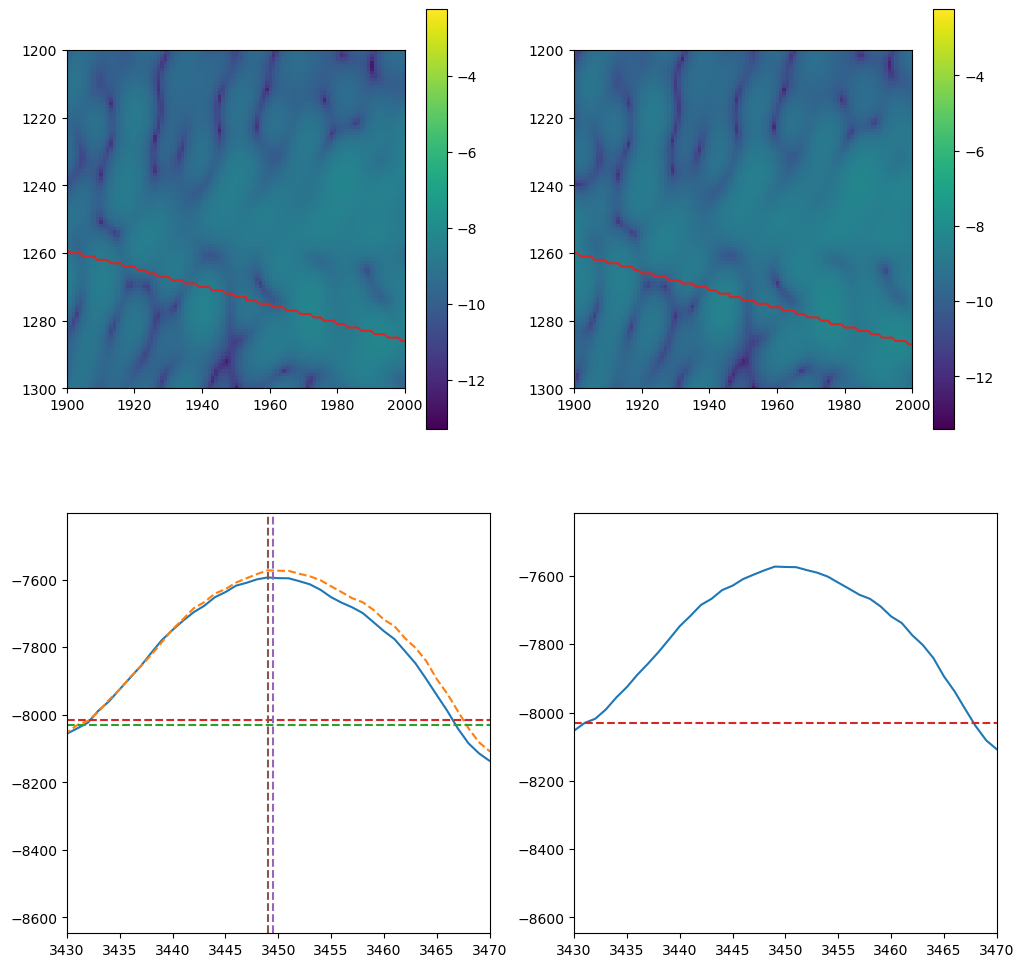

In [26]:
figA, axA = plt.subplots( figsize=( 12, 12 ), ncols=2, nrows=2 )
im = axA[0,0].imshow( psf_hcenter_pos )
figA.colorbar( im, ax=axA[0,0] )

im = axA[0,1].imshow( psf_ideal )
figA.colorbar( im, ax=axA[0,1] )

for s_hc, s_id in zip( spike_list_hcenter_pos, spike_list_ideal ):
    draw_ray( axA[0,0], s_hc, bound, center, color="C3" )
    draw_ray( axA[0,1], s_id, bound, center, color="C3" )

zoom_x = ( 1900, 2000 )
zoom_y = ( 1300, 1200 )
axA[0,0].set_xlim( zoom_x )
axA[0,0].set_ylim( zoom_y )

axA[0,1].set_xlim( zoom_x )
axA[0,1].set_ylim( zoom_y )

zoom2_x = ( 3430, 3470 )
axA[1,0].plot( sums_hcenter_pos )
axA[1,1].plot( sums_ideal )
axA[1,0].plot( sums_ideal, ls='--' )
axA[1,0].axhline( cutoff_hcenter_pos, color="C3", ls='--' )
axA[1,0].axhline( cutoff_ideal, color="C2", ls='--' )
axA[1,1].axhline( cutoff_ideal, color="C3", ls='--' )

axA[1,0].axvline( spike_list_hcenter_pos[11]*10, ls='--', color="C4" )
axA[1,0].axvline( spike_list_ideal[11]*10, ls='--', color="C5" )

axA[1,0].set_xlim( zoom2_x )
axA[1,1].set_xlim( zoom2_x )

In [27]:
obj = PSFObject(
    9,0,0, wavelength=1.25, postage_stamp_size=32, use_postage_stamp_size=None,
    extra_aberrations=( None, 0.2, )
)
obj.get_optical_psf( )
psf_vcenter_pos = np.log10( np.abs( obj.Optical_PSF ) )

/apps/python/3.12/lib/python3.12/site-packages/numpy/core/fromnumeric.py:3504: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/apps/python/3.12/lib/python3.12/site-packages/numpy/core/_methods.py:121: RuntimeWarning: invalid value encountered in divide
  ret = um.true_divide(


Bounding pupil width determined from initial ray trace: 2859.38 mm


In [28]:
obj = PSFObject(
    9,0,0, wavelength=1.25, postage_stamp_size=32, use_postage_stamp_size=None,
    extra_aberrations=( None, -0.2, )
)
obj.get_optical_psf( )
psf_vcenter_neg = np.log10( np.abs( obj.Optical_PSF ) )

/apps/python/3.12/lib/python3.12/site-packages/numpy/core/fromnumeric.py:3504: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/apps/python/3.12/lib/python3.12/site-packages/numpy/core/_methods.py:121: RuntimeWarning: invalid value encountered in divide
  ret = um.true_divide(


Bounding pupil width determined from initial ray trace: 2859.38 mm


In [29]:
obj = PSFObject(
    9,0,0, wavelength=1.25, postage_stamp_size=32, use_postage_stamp_size=None,
    extra_aberrations=( None, 0.06, )
)
obj.get_optical_psf( )
psf_vcenter_small = np.log10( np.abs( obj.Optical_PSF ) )

/apps/python/3.12/lib/python3.12/site-packages/numpy/core/fromnumeric.py:3504: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/apps/python/3.12/lib/python3.12/site-packages/numpy/core/_methods.py:121: RuntimeWarning: invalid value encountered in divide
  ret = um.true_divide(


Bounding pupil width determined from initial ray trace: 2859.38 mm


(3600, 1024)
(3600, 1024)
(3600, 1024)


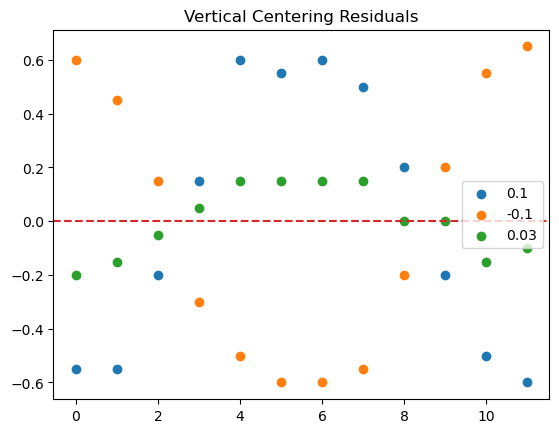

In [30]:
spike_list_vcenter_pos = find_spikes( psf_vcenter_pos, step, bound, center )
spike_list_vcenter_neg = find_spikes( psf_vcenter_neg, step, bound, center )
spike_list_vcenter_small = find_spikes( psf_vcenter_small, step, bound, center )
N = np.arange( spike_list_ideal.size )

fig5, ax5 = plt.subplots( )
ax5.scatter( N, spike_list_vcenter_pos - spike_list_ideal, label='0.1' )
ax5.scatter( N, spike_list_vcenter_neg - spike_list_ideal, label='-0.1' )
ax5.scatter( N, spike_list_vcenter_small - spike_list_ideal, label='0.03' )
ax5.axhline( 0, color='C3', ls='--' )
ax5.set_title( 'Vertical Centering Residuals' )
ax5.legend( );
# print( ( spike_list_hcenter_pos - spike_list_ideal )[11] )